## Importing the Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib.patches import Ellipse


## Loading the Dataset

In [ ]:
df = pd.read_csv('/content/Mall_Customers.csv')
df = df.dropna()
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Preprocessing and Feature Selection

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Choose Number of Components using BIC

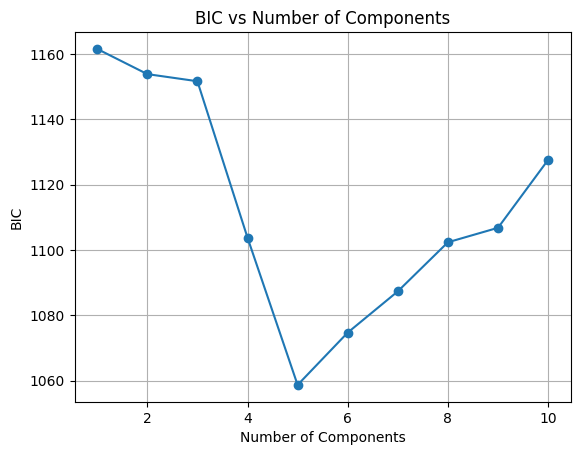

In [ ]:
bic_scores = []
components = range(1, 11)

for n in components:
    gmm_temp = GaussianMixture(n_components=n, random_state=42)
    gmm_temp.fit(X_scaled)
    bic_scores.append(gmm_temp.bic(X_scaled))

plt.figure()
plt.plot(components, bic_scores, marker='o')
plt.title('BIC vs Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('BIC')
plt.grid(True)
plt.show()


## Fit GMM using Expectation-Maximization (EM)

In [ ]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)


GaussianMixture(n_components=5, random_state=42)

## Predict Cluster Probabilities

In [ ]:
probs = gmm.predict_proba(X_scaled)
probs[:5]

array([[1.57689698e-05, 1.88009163e-08, 9.52031247e-04, 5.20013085e-08,
        9.99032129e-01],
       [1.62776204e-05, 1.89596786e-04, 9.99790184e-01, 4.21013390e-23,
        3.94154449e-06],
       [2.21339374e-19, 9.52615737e-19, 1.22549539e-12, 1.86223280e-04,
        9.99813777e-01],
       [1.05444778e-04, 1.80087695e-04, 9.99693745e-01, 3.79390067e-21,
        2.07229768e-05],
       [6.47301428e-05, 3.84273231e-08, 1.55669540e-03, 4.75722704e-08,
        9.98378488e-01]])

## Assign Clusters Based on Highest Probability

In [ ]:
labels_gmm = np.argmax(probs, axis=1)
df['GMM_Cluster'] = labels_gmm
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),GMM_Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Compare with K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)


## Evaluation Metrics

In [ ]:
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score (GMM):", silhouette_score(X_scaled, labels_gmm))
print("Silhouette Score (KMeans):", silhouette_score(X_scaled, labels_kmeans))


Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score (GMM): 0.5536892843811245
Silhouette Score (KMeans): 0.5546571631111091


## GMM Cluster Scatter Plot

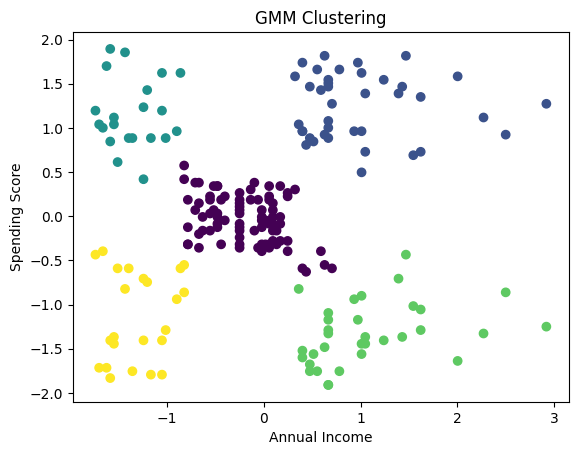

In [ ]:
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_gmm)
plt.title('GMM Clustering')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()


## Cluster Probability Distribution

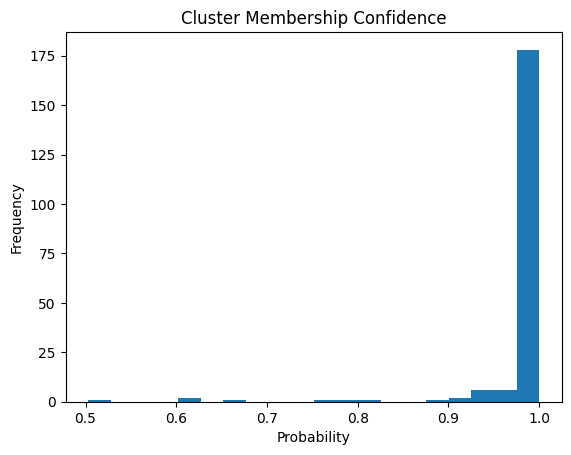

In [ ]:
plt.figure()
plt.hist(probs.max(axis=1), bins=20)
plt.title('Cluster Membership Confidence')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.show()


## GMM Contour Plot

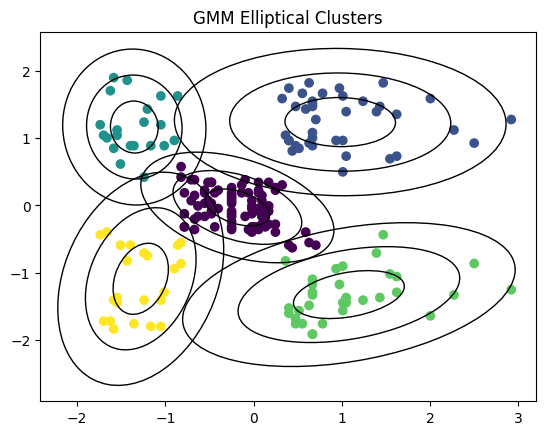

In [ ]:
def draw_ellipse(position, covariance, ax):
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)

    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, nsig*width, nsig*height, angle=angle, fill=False))

plt.figure()
ax = plt.gca()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_gmm)

for i in range(gmm.n_components):
    draw_ellipse(gmm.means_[i], gmm.covariances_[i], ax)

plt.title('GMM Elliptical Clusters')
plt.show()

## K-Means vs GMM Comparison

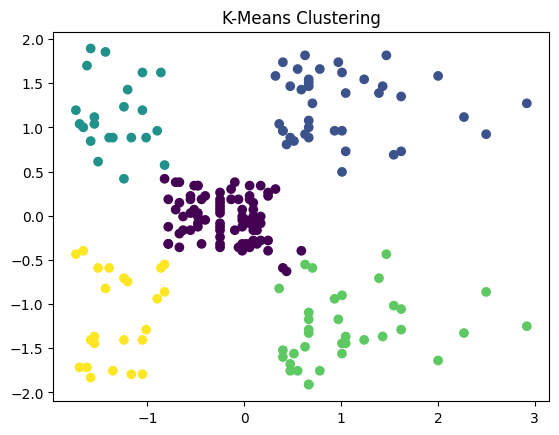

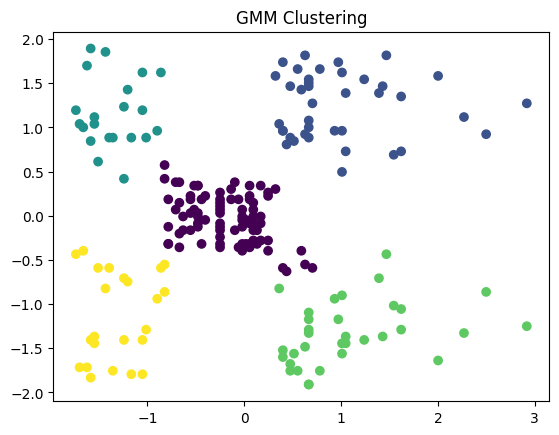

In [ ]:
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans)
plt.title('K-Means Clustering')
plt.show()

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_gmm)
plt.title('GMM Clustering')
plt.show()
